In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as sp_stats
from sparrow import Protein
from scipy.optimize import curve_fit
from scipy.stats import t as t_dist
from matplotlib.lines import Line2D


plt.rcParams['svg.fonttype'] = 'none'

In [ ]:
construct_stats = pd.read_csv('../../Data/Figures_2-3-4/constructs_df.csv', index_col=0)

construct_stats['construct'] = construct_stats['construct'].astype(str)

In [3]:
# Function to calculate sequence features and predictions using sparrow
def calculate_sparrow_features(seqs_df):
    features = []
    for idx, row in seqs_df.iterrows():
        seq = row['sequence']
        construct = row['construct']
        protein = Protein(seq)
        
        # Calculate features
        f_positive = protein.fraction_positive
        f_negative = protein.fraction_negative
        aro = protein.fraction_aromatic
        ali = protein.fraction_aliphatic
        polar = protein.fraction_polar
        proline = protein.fraction_proline
        scd = protein.SCD                    # Uppercase SCD
        shd = protein.SHD                    # Uppercase SHD
        ncpr = protein.NCPR                  # Uppercase NCPR
        fcr = protein.FCR                    # Uppercase FCR
        hydrophobicity = protein.hydrophobicity
        kappa = protein.kappa
        
        # Predictions
        rg = protein.predictor.radius_of_gyration()
        re = protein.predictor.end_to_end_distance()
        mean_disorder = np.mean(protein.predictor.disorder())
        asphericity = protein.predictor.asphericity()
        scaling_exp = protein.predictor.scaling_exponent()
        prefactor = protein.predictor.prefactor()
        coil = protein.predictor.dssp_coil()
        extended = protein.predictor.dssp_extended()
        helicity = protein.predictor.dssp_helicity()
        
        features.append({
            'construct': construct,
            'f_positive': f_positive,
            'f_negative': f_negative,
            'aro': aro,
            'ali': ali,
            'polar': polar,
            'proline': proline,
            'scd': scd,
            'shd': shd,
            'NCPR': ncpr,
            'FCR': fcr,
            'hydrophobicity': hydrophobicity,
            'kappa': kappa,
            'rg': rg,
            're': re,
            'mean_disorder': mean_disorder,
            'asphericity': asphericity,
            'scaling_exponent': scaling_exp,
            'prefactor': prefactor,
            'coil': coil,
            'extended': extended,
            'helicity': helicity
        })
    return pd.DataFrame(features)

# Calculate features and predictions, then merge with construct_stats
sparrow_features = calculate_sparrow_features(construct_stats)
construct_stats = construct_stats.merge(sparrow_features, on='construct', how='left')

Error importing GPy.
 If trying to run parrot-optimize, make sure to use `pip install idptools-parrot[optimize]`


In [4]:
construct_stats['construct'] = construct_stats['construct'].astype(int)

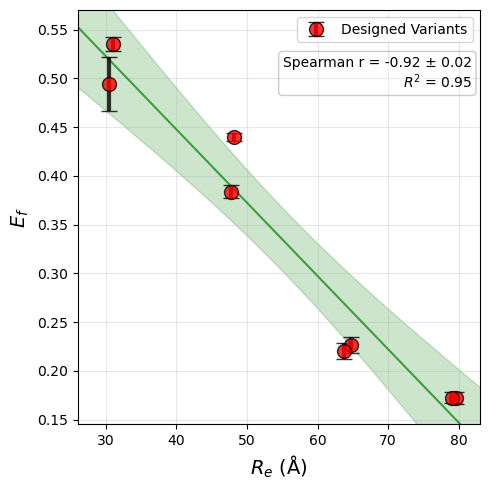

In [ ]:
# Filter for construct > 34
designed_constructs = construct_stats[construct_stats['construct'] > 34].copy()

# Monte Carlo sampling for Spearman correlation
n_iterations = 1000
spearman_values = []

for _ in range(n_iterations):
    sampled_y = []
    
    for idx, row in designed_constructs.iterrows():
        # Sample from normal distribution for Ef_cell only (Re stays constant)
        sampled_y_val = np.random.normal(row['Ef_cell'], row['Ef_cell_std'])
        sampled_y.append(sampled_y_val)
    
    # Calculate Spearman correlation for this iteration
    spearman_r_sample, _ = sp_stats.spearmanr(designed_constructs['re'], sampled_y)
    spearman_values.append(spearman_r_sample)

# Calculate mean and std of Spearman correlations
spearman_r_mean = np.mean(spearman_values)
spearman_r_std = np.std(spearman_values)

# Linear regression
def linear_function(x, slope, intercept):
    return slope * x + intercept

x_data = designed_constructs['re'].values
y_data = designed_constructs['Ef_cell'].values

popt, pcov = curve_fit(linear_function, x_data, y_data)
slope, intercept = popt

# Calculate R-squared and residual standard error
residuals = y_data - linear_function(x_data, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - (ss_res / ss_tot)

# Calculate 95% confidence interval
n = len(x_data)
dof = n - 2
residual_std_error = np.sqrt(ss_res / dof)
t_val = t_dist.ppf(0.975, dof)

# Generate line for plotting
x_fit = np.linspace(-20, 90, 200)
y_fit = linear_function(x_fit, slope, intercept)

# 95% confidence interval for the prediction
se_line = residual_std_error * np.sqrt(1/n + (x_fit - np.mean(x_data))**2 / np.sum((x_data - np.mean(x_data))**2))
y_upper = y_fit + t_val * se_line
y_lower = y_fit - t_val * se_line

# Create plot
fig, ax = plt.subplots(figsize=(5, 5))

# Plot confidence band first
ax.fill_between(x_fit, y_lower, y_upper, color='green', alpha=0.2, zorder=1)

# Plot fit line
ax.plot(x_fit, y_fit, color='green', linewidth=1.5, alpha=0.7, zorder=2)

# Plot data points
ax.errorbar(designed_constructs['re'], designed_constructs['Ef_cell'], 
           yerr=designed_constructs['Ef_cell_std'], fmt='o', 
           markeredgecolor='black', alpha=0.8, color='red', capsize=6, linewidth=3, ms=10,
           ecolor='black', label='Designed Variants', zorder=3)

plt.xlim(26, 83)
plt.ylim(.145, .57)
ax.set_xlabel(r'$R_e$ (Å)', fontsize=14)
ax.set_ylabel(r'$E_{f}$', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', frameon=True, fontsize=10)

ax.text(0.98, 0.89, f'Spearman r = {spearman_r_mean:.2f} ± {spearman_r_std:.2f}\n$R^2$ = {r_squared:.2f}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.2))

plt.tight_layout()
#plt.savefig('Ef_vs_Re_designed.svg')
plt.show()